In [9]:
import numpy as np

from rose.data import training_data
from rose.viz import plot_prediction_scatter

In [2]:
X_train, y_train = training_data(N=4, seed=37)
X_test, y_test = training_data(N=1_000, seed=42)

print(X_train.shape, y_train.shape)

(4, 5) (4,)


In [3]:
for x, target in zip(X_train, y_train):
    print(*x, "->", target, sep="\t")

4	5	4	5	6	->	8.0
3	4	4	3	6	->	4.0
1	6	1	1	4	->	0.0
3	5	1	5	3	->	12.0


In [4]:
# Count data
def counts(X):
    return np.array([np.bincount(row, minlength=7)[1:7] for row in X])


C_train = counts(X_train)
C_test = counts(X_test)

In [5]:
for x, target in zip(C_train, y_train):
    print(*x, "|", target, sep="\t")

0	0	0	2	2	1	|	8.0
0	0	2	2	0	1	|	4.0
3	0	0	1	0	1	|	0.0
1	0	2	0	2	0	|	12.0


In [6]:
solution, residuals, rank, singular_values = np.linalg.lstsq(
    C_train, y_train, rcond=None
)
solution

array([ 2.69662921e-02, -1.94289029e-16,  1.99325843e+00,  9.43820225e-02,
        3.99325843e+00, -1.75280899e-01])

In [7]:
# predict the number of petals from the fitted coefficients
y_test_hat = C_test @ solution
y_test_hat.shape

(1000,)

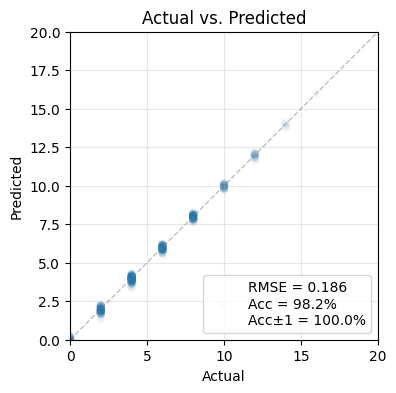

In [10]:
plot_prediction_scatter(
    y_test,
    y_test_hat,
    title="Actual vs. Predicted",
)